<a href="https://colab.research.google.com/github/UFPAJoaoVictorIA/Atividade-Extra-Questoes-Resolvidas-Parte-Final-Claudomiro/blob/main/Atividade_Extra_Questoes_Resolvidas_Parte_Final_Claudomiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### UFPA - Faculdade de Computação (FACOMP)
**Curso:** Inteligência Artificial  
**Disciplina:** Organização e Arquitetura de Computadores  
**Atividade:** Atividade Extra  
**Aluno:** João Victor  
**Professor:** Claudomiro Sales  

---

### Questão 1: Funções Básicas da UCP e Componentes
**Enunciado:** Descreva as funções básicas de uma UCP, indicando os seus componentes principais.

**Explicação:** A Unidade Central de Processamento (UCP ou CPU) é o 'cérebro' do computador. Suas funções básicas são:
1. **Busca:** Obter a instrução da memória.
2. **Decodificação:** Interpretar o que a instrução deve fazer.
3. **Execução:** Realizar a operação.

Seus componentes principais são a Unidade de Controle (UC), a Unidade Lógica e Aritmética (ULA) e os Registradores.

In [ ]:
class CPU:
    def __init__(self):
        self.UC = "Unidade de Controle (Coordena as atividades)"
        self.ULA = "Unidade Lógica e Aritmética (Realiza cálculos)"
        self.Registradores = "Memória de alta velocidade interna"

    def ciclo_instrucao(self):
        print(f"1. Busca: A {self.UC} busca a instrução na memória.")
        print(f"2. Decodificação: A {self.UC} interpreta a instrução.")
        print(f"3. Execução: A {self.ULA} processa os dados.")

cpu_demo = CPU()
cpu_demo.ciclo_instrucao()

1. Busca: A Unidade de Controle (Coordena as atividades) busca a instrução na memória.
2. Decodificação: A Unidade de Controle (Coordena as atividades) interpreta a instrução.
3. Execução: A Unidade Lógica e Aritmética (Realiza cálculos) processa os dados.


### Questão 2: Funções da Unidade Aritmética e Lógica (UAL)
**Enunciado:** Quais são as funções da unidade aritmética e lógica - UAL?

**Explicação:** A UAL é responsável por todas as operações de processamento de dados do processador. Ela realiza operações aritméticas (soma, subtração) e operações lógicas (AND, OR, NOT, comparações).

In [ ]:
def ual_simulada(op1, op2, operacao):
    if operacao == 'ADD': return op1 + op2
    if operacao == 'SUB': return op1 - op2
    if operacao == 'AND': return op1 & op2
    if operacao == 'OR':  return op1 | op2
    return None

print(f"Aritmética (Soma): 10 + 5 = {ual_simulada(10, 5, 'ADD')}")
print(f"Lógica (AND): 1 & 1 = {ual_simulada(1, 1, 'AND')}")

Aritmética (Soma): 10 + 5 = 15
Lógica (AND): 1 & 1 = 1


### Questão 3: O Acumulador (ACC)
**Enunciado:** O que é e para que servia o ACC?

**Explicação:** O Acumulador é um registrador especial onde os resultados intermediários de uma operação da ULA são armazenados. Em arquiteturas antigas, quase todas as operações envolviam implicitamente o ACC.

In [ ]:
class ProcessadorComACC:
    def __init__(self):
        self.ACC = 0

    def somar(self, valor):
        print(f"Somando {valor} ao Acumulador ({self.ACC})...")
        self.ACC += valor
        print(f"Novo valor no ACC: {self.ACC}")

proc = ProcessadorComACC()
proc.somar(15)
proc.somar(10)

Somando 15 ao Acumulador (0)...
Novo valor no ACC: 15
Somando 10 ao Acumulador (15)...
Novo valor no ACC: 25


### Questão 5: Funções da Unidade de Controle (UC)
**Enunciado:** Quais são as funções da unidade de controle de um processador?

**Explicação:** A UC gerencia o fluxo de dados dentro da CPU e entre a CPU e periféricos. Ela busca, decodifica instruções e gera sinais de controle para que a ULA e a Memória saibam o que fazer.

### Questão 6: CI vs REM
**Enunciado:** Seria possível realizar o projeto de um processador em que o tamanho em bits do CI fosse diferente do tamanho do REM? Nesse caso, qual dos dois registradores deveria ter maior tamanho? Por quê?

**Explicação:** Sim, é possível. O REM (Registrador de Endereços de Memória) deve ter o tamanho necessário para endereçar toda a memória física. O CI (Contador de Instrução) aponta para a próxima instrução. Se o CI for menor, o programa ficaria restrito a uma parte da memória. Geralmente eles têm o mesmo tamanho para que o CI possa acessar qualquer endereço que o REM suporte.

### Questão 7: Incremento Automático do CI
**Enunciado:** Considere um computador cuja MP é organizada com N células de 1 byte cada uma. As instruções possuem três tamanhos: tipo A (16 bits), tipo B (32 bits) e tipo C (48 bits). O C.Op tem tamanho fixo de 8 bits. Imagine um processo prático para incremento automático do CI.

**Explicação e Passo a Passo:**
Como cada célula de memória armazena 8 bits (1 byte), o CI (Contador de Instrução) deve ser incrementado pelo número de bytes que a instrução ocupa.

1. **Busca do C.Op:** A CPU busca o primeiro byte da instrução (o C.Op de 8 bits) no endereço indicado pelo CI.
2. **Decodificação:** A Unidade de Controle identifica o tipo da instrução através do C.Op.
3. **Cálculo do Salto:**
   - Se for **Tipo A (16 bits)**: Ocupa 2 bytes. O CI deve ser incrementado em **+2**.
   - Se for **Tipo B (32 bits)**: Ocupa 4 bytes. O CI deve ser incrementado em **+4**.
   - Se for **Tipo C (48 bits)**: Ocupa 6 bytes. O CI deve ser incrementado em **+6**.
4. **Atualização:** O hardware da Unidade de Controle soma esse valor ao CI logo após a identificação do tamanho, preparando-o para a próxima busca enquanto a instrução atual ainda é executada.

In [1]:
def simular_incremento_ci(ci_atual, c_op):
    # Tabela teórica de C.Op para identificar o tipo
    tabela_instrucoes = {
        '0x10': {'tipo': 'A', 'bits': 16}, # 2 bytes
        '0x20': {'tipo': 'B', 'bits': 32}, # 4 bytes
        '0x30': {'tipo': 'C', 'bits': 48}  # 6 bytes
    }

    info = tabela_instrucoes.get(c_op)
    bytes_ocupados = info['bits'] // 8
    novo_ci = ci_atual + bytes_ocupados

    print(f"Endereço Atual (CI): {ci_atual}")
    print(f"Instrução detectada: Tipo {info['tipo']} ({info['bits']} bits)")
    print(f"Incremento aplicado: +{bytes_ocupados} bytes")
    print(f"Próximo endereço (Novo CI): {novo_ci}\n")
    return novo_ci

# Simulação de um programa executando instruções sequenciais
posicao_memoria = 1000
posicao_memoria = simular_incremento_ci(posicao_memoria, '0x10') # A
posicao_memoria = simular_incremento_ci(posicao_memoria, '0x30') # C
posicao_memoria = simular_incremento_ci(posicao_memoria, '0x20') # B

Endereço Atual (CI): 1000
Instrução detectada: Tipo A (16 bits)
Incremento aplicado: +2 bytes
Próximo endereço (Novo CI): 1002

Endereço Atual (CI): 1002
Instrução detectada: Tipo C (48 bits)
Incremento aplicado: +6 bytes
Próximo endereço (Novo CI): 1008

Endereço Atual (CI): 1008
Instrução detectada: Tipo B (32 bits)
Incremento aplicado: +4 bytes
Próximo endereço (Novo CI): 1012



### Questão 8: Ciclo sem Incremento Automático
**Enunciado:** Imagine um método alternativo para execução sem incremento automático do CI.

**Explicação:** Se o hardware não incrementa o CI automaticamente, cada instrução deve conter explicitamente o endereço da próxima instrução a ser executada (encadeamento de instruções).

In [ ]:
# Simulação de instrução que carrega o próximo endereço
memoria = {
    10: {'op': 'SOMA', 'proximo': 20},
    20: {'op': 'SUB', 'proximo': 35},
    35: {'op': 'HALT', 'proximo': None}
}

ci = 10
while ci is not None:
    instrucao = memoria[ci]
    print(f"Executando {instrucao['op']} no endereço {ci}")
    ci = instrucao['proximo']

Executando SOMA no endereço 10
Executando SUB no endereço 20
Executando HALT no endereço 35


### Questão 9: Controle da Sequência
**Enunciado:** Qual é e onde se localiza o registrador cujo conteúdo controla a seqüência de processamento das instruções?

**Explicação:** É o **Contador de Instrução (CI)** ou *Program Counter* (PC). Ele se localiza dentro da Unidade de Controle na UCP.

### Questão 11: Capacidade de Memória
**Enunciado:** Qual é o registrador cujo conteúdo determina a capacidade de memória de um computador? Justifique.

**Explicação:** É o **REM (Registrador de Endereço de Memória)**. O número de bits do REM define quantas combinações de endereços únicos podem ser geradas ($2^n$).

In [ ]:
import math

def capacidade_bits(bits_rem):
    celulas = 2 ** bits_rem
    return celulas

print(f"Com 16 bits no REM, podemos acessar {capacidade_bits(16)} células.")

Com 16 bits no REM, podemos acessar 65536 células.


### Questão 15: Micro de 8 vs 16 bits
**Enunciado:** Quando se fala que um determinado microcomputador A é um micro de 8 bits e que um outro micro B é de 16 bits, a que estamos nos referindo? Ao tamanho da célula de MP ou ao tamanho da palavra? Qual a base desses dois conceitos (palavra e célula)?

**Explicação:**
Referimo-nos ao **tamanho da Palavra** do processador.

1.  **Célula:** É a menor unidade de memória que possui um endereço próprio. Na maioria das arquiteturas modernas, a célula é de 8 bits (1 byte).
2.  **Palavra:** É a quantidade de bits que a CPU consegue processar em uma única operação (tamanho dos registradores internos e largura da ULA).

**Diferença Fundamental:**
- Um micro de **8 bits** processa operandos de até 8 bits por vez. Se precisar somar números de 16 bits, precisará de múltiplos ciclos.
- Um micro de **16 bits** possui barramentos internos e ULA maiores, permitindo processar dados mais complexos em um único ciclo, aumentando o desempenho.

### Questão 18: Processamento Sequencial vs. Pipeline
**Enunciado:** Explique a diferença entre um processamento seqüencial e um outro pipeline.

**Explicação:**

1.  **Processamento Sequencial:**
    - O processador executa uma instrução por vez de forma rígida.
    - Uma nova instrução só começa a ser buscada após a instrução anterior ter passado por todos os estágios (Busca, Decodificação, Execução).
    - **Analogia:** Imagine lavar roupa onde você só coloca a segunda trouxa na máquina de lavar depois que a primeira já foi lavada, seca e dobrada.

2.  **Pipeline (Processamento em Estágios):**
    - Divide a execução em vários estágios independentes.
    - Permite que várias instruções ocupem diferentes estágios simultaneamente.
    - Enquanto a instrução $N$ está sendo executada, a instrução $N+1$ está sendo decodificada e a $N+2$ está sendo buscada.
    - **Vantagem:** Aumenta o número de instruções finalizadas por segundo (*throughput*), embora o tempo individual de cada uma continue o mesmo.

**Resolução em Python:**
Abaixo, simulamos matematicamente o tempo de execução comparando os dois modelos para entender o ganho de eficiência.

def comparar_modelos(n_instrucoes):
    # No sequencial, cada instrução leva 3 ciclos (Busca, Decod, Exec)
    ciclos_sequencial = n_instrucoes * 3
    
    # No pipeline (ideal), a primeira leva 3 ciclos, e as demais terminam 1 por ciclo
    # Fórmula: (estágios + n - 1)
    ciclos_pipeline = 3 + n_instrucoes - 1
    
    print(f"Simulação para {n_instrucoes} instruções:")
    print(f"- Modelo Sequencial: {ciclos_sequencial} ciclos")
    print(f"- Modelo Pipeline:   {ciclos_pipeline} ciclos")
    if ciclos_pipeline > 0:
        ganho = ((ciclos_sequencial / ciclos_pipeline) - 1) * 100
        print(f"Ganho de eficiência: {ganho:.2f}%")

comparar_modelos(10)

In [11]:
def simular_processamento(n_instrucoes):
    """
    Simula a diferença de tempo entre processamento sequencial e pipeline.
    Considerando 3 estágios: Busca (B), Decodificação (D) e Execução (E).
    """
    # 1. Modelo Sequencial: Cada instrução espera a anterior terminar todos os estágios
    # Tempo = n_instrucoes * num_estagios
    tempo_sequencial = n_instrucoes * 3

    # 2. Modelo Pipeline: As instruções entram no fluxo a cada ciclo
    # Tempo = tempo_da_primeira + (instrucoes_restantes * 1)
    # Fórmula: k + (n - 1), onde k é o número de estágios
    tempo_pipeline = 3 + (n_instrucoes - 1)

    print(f"--- Simulação para {n_instrucoes} Instruções ---")
    print(f"Tempo Sequencial: {tempo_sequencial} ciclos")
    print(f"Tempo Pipeline:   {tempo_pipeline} ciclos")

    ganho = ((tempo_sequencial / tempo_pipeline) - 1) * 100
    print(f"Ganho de Velocidade (Speedup): {ganho:.2f}%")

# Passo a passo da resolução:
# 1. Definimos o número de estágios (3: Busca, Decodificação, Execução)
# 2. Calculamos o custo total para processar 10 instruções de forma isolada
# 3. Calculamos o custo aproveitando o paralelismo temporal (Pipeline)
simular_processamento(10)

--- Simulação para 10 Instruções ---
Tempo Sequencial: 30 ciclos
Tempo Pipeline:   12 ciclos
Ganho de Velocidade (Speedup): 150.00%


### Questão 22: Cálculo de Campos de Instrução

**Enunciado Completo:**
Considere um processador que possua um conjunto de instruções sobre o qual foi feito um extrato das mais importantes na tabela a seguir. Neste processador todos os endereços possuem 16 bits e as instruções possuem um formato único (**C.Op. | Reg. | Op. 2**), e ele possui um conjunto de 16 registradores de dados. Suponha que em um determinado instante, correspondente ao término da execução de uma instrução qualquer, o CI tenha armazenado o seguinte valor: **CI = 2B78 (Hexa)**, e que o registrador RI tenha armazenado o seguinte valor: **RI = 2C4F08D9 (Hexa)**.

**Tabela de Instruções (Extrato):**
| C.Op. (Hexa) | Sigla | Descrição |
|---|---|---|
| 00 | HLT | Parar |
| 01 | MOV R, Op. | R ← (Op.) |
| 02 | MOVM Op., R | (Op.) ← (R) |
| 10 | JMP R, Op. | CI ← Op. |
| 11 | JP R, Op. | Se R > 0, então: CI ← Op. |
| 12 | JN R, Op. | Se R < 0, então: CI ← Op. |
| 13 | JZ R, Op. | Se R = 0, então: CI ← Op. |
| 20 | ADD R, Op. | (R) ← (R) + Op. |
| 21 | SUB R, Op. | (R) ← (R) - Op. |

**Respostas e Análise:**
*   **Análise do RI (2C4F08D9):** O RI possui 32 bits (8 dígitos hexadecimais).
*   **a) Largura do campo Reg:** Como o processador possui 16 registradores, são necessários **4 bits** ($2^4 = 16$).
*   **b) Largura do campo Op. 2 (Endereço):** O enunciado afirma que todos os endereços possuem **16 bits**.
*   **c) Largura do campo C.Op:** Se o total são 32 bits, subtraímos o endereço (16) e o registrador (4), restando **12 bits** para o C.Op.
*   **d) Acessos à memória:**
    *   **C.Op 11 (JP):** Requer **1 acesso** (Busca da instrução). A comparação é feita com o registrador e o salto altera o CI, sem nova leitura de dado na memória.
    *   **C.Op 21 (SUB):** Requer **1 acesso** (Busca da instrução). A operação ocorre entre o registrador e o valor imediato (Op. 2) contido na própria instrução.

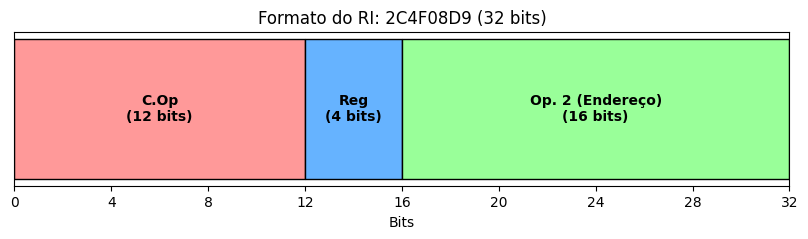

Análise Final:
- Largura Reg: 4 bits (para 16 registradores)
- Acessos C.Op 11: 1 (Busca)
- Acessos C.Op 21: 1 (Busca)


In [ ]:
import matplotlib.pyplot as plt

# Dados da partição
ri_hex = "2C4F08D9"
ri_bits = 32
endereco_bits = 16
reg_bits = 4
cop_bits = 12

# Visualização do Formato da Instrução
labels = [f'C.Op\n({cop_bits} bits)', f'Reg\n({reg_bits} bits)', f'Op. 2 (Endereço)\n({endereco_bits} bits)']
sizes = [cop_bits, reg_bits, endereco_bits]
colors = ['#ff9999','#66b3ff','#99ff99']

fig, ax = plt.subplots(figsize=(10, 2))
start = 0
for label, size, color in zip(labels, sizes, colors):
    ax.barh(0, size, left=start, color=color, edgecolor='black', label=label)
    ax.text(start + size/2, 0, label, ha='center', va='center', fontweight='bold')
    start += size

ax.set_xlim(0, 32)
ax.set_xticks(range(0, 33, 4))
ax.set_yticks([])
ax.set_title(f"Formato do RI: {ri_hex} (32 bits)")
plt.xlabel("Bits")
plt.show()

print(f"Análise Final:")
print(f"- Largura Reg: {reg_bits} bits (para 16 registradores)")
print(f"- Acessos C.Op 11: 1 (Busca)")
print(f"- Acessos C.Op 21: 1 (Busca)")